<a href="https://colab.research.google.com/github/Frankieche24/White-Wine-Quality/blob/main/notebooks/T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [2]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

##Answers to Question 1

**A. What is the type of objects yielded by the dataloaders?**
Each dataloader yields a tuple of two torch.Tensor objects: (images, labels).The tensor has a shape of batch size 64.(64 images per batch)

**B. What is the shape of images from train_loader? How do you interpret that shape?**
The shape is [64, 64]: which is the batch size(64 images per batch) and input size (each image flattened 8 × 8 = 64 pixels)

**C. Why does train use shuffle=True but test uses shuffle=False?**
Training shuffles the data so the model does not memorise the order of examples,
which prevents order-dependent bias. Testing does not shuffle because order does
not affect evaluation metrics, and keeping it fixed ensures reproducible results.

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

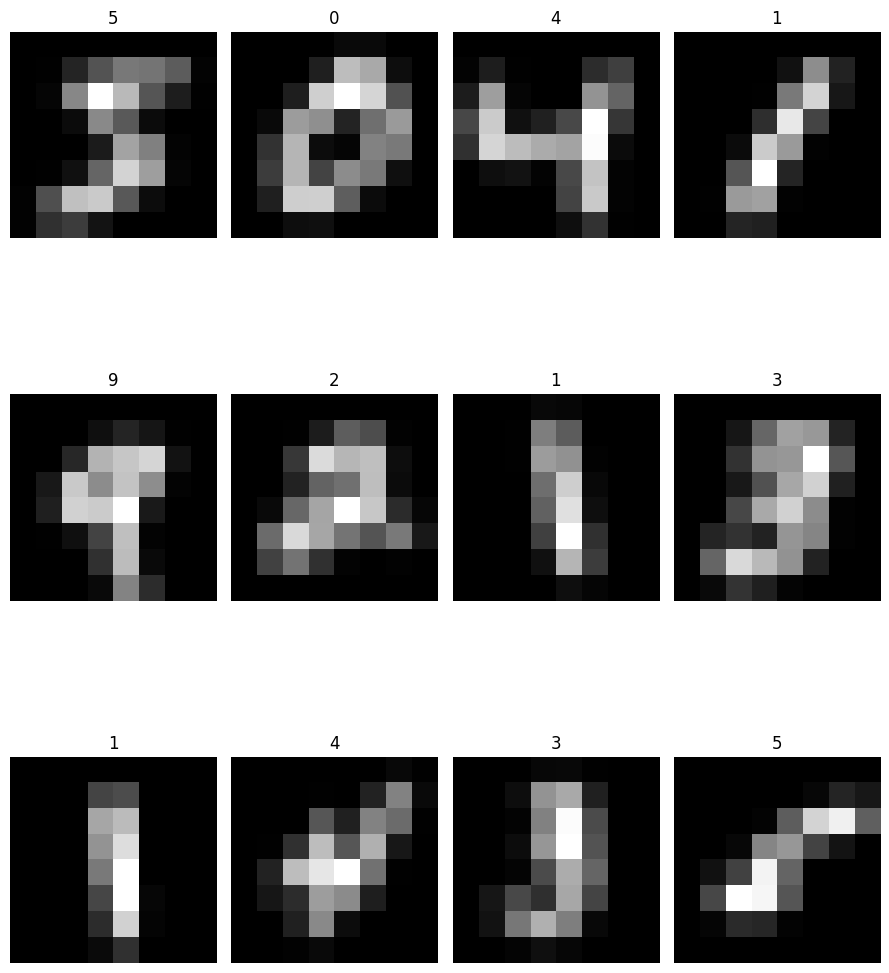

In [5]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [6]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

## Answers to Question:

**A. Changes for using original 28x28 MNIST image size:**
   - **Data Transformation:** In the `transform` definition (cell `Xd5AJl9TrYTB`), remove or adjust `transforms.Resize((8, 8))` to either not resize or resize to 28x28. Also, the `transforms.Lambda(lambda x: x.view(-1))` would then flatten a `28 * 28` image.
   - **Model Input Size:** The `input_size` for the `SimpleNN` model (cell `Onqhot-Fw-mX`) needs to be updated from `8 * 8` to `28 * 28 = 784`.

**B. Change to `SimpleNN` for two hidden layers, both with size 128:**
   You would modify the `SimpleNN` class (cell `Onqhot-Fw-mX`) as follows:
   ```python
   class SimpleNN(nn.Module):
       def __init__(self, input_size, hidden_size, num_classes):
           super(SimpleNN, self).__init__()
           self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
           self.relu1 = nn.ReLU()
           self.fc2 = nn.Linear(hidden_size, hidden_size)  # Second hidden layer
           self.relu2 = nn.ReLU()
           self.fc3 = nn.Linear(hidden_size, num_classes) # Output layer

       def forward(self, x):
           out = self.fc1(x)
           out = self.relu1(out)
           out = self.fc2(out)
           out = self.relu2(out)
           out = self.fc3(out)
           return out
   ```

**C. What is a `ReLU` activation function called by `nn.ReLU`?**
   `ReLU` stands for **Rectified Linear Unit**. It is an activation function defined as $f(x) = \max(0, x)$. This means it outputs the input directly if it's positive, and outputs zero otherwise.

**D. Why are non-linear activation functions like `ReLU` necessary for deep learning?**
   Non-linear activation functions are crucial because they introduce non-linearity into the neural network. Without them, a neural network, regardless of its depth, would behave like a single linear model. This would severely limit its ability to learn complex patterns and relationships in data. `ReLU` and other non-linear activations allow neural networks to approximate any arbitrary function, making them powerful tools for tasks like image recognition, natural language processing, and more.

In [ ]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [7]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

epoch: 1; time: 1780578904
epoch: 2; time: 1780578916
epoch: 3; time: 1780578925


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




##Answer to Question 3

The experiment below trains the model for 3 epochs twice — once without
num_workers and once with num_workers=2 — and compares the total training time.

In [15]:
# Common setup for both runs
num_epochs_comparison = 3

# Ensure the device is set (CPU or CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Run 1: Training without `num_workers`

In [22]:
# Re-initialize model and optimizer for the first run
model_no_workers = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer_no_workers = optim.Adam(model_no_workers.parameters(), lr=0.001)

# Create DataLoaders WITHOUT num_workers
train_loader_no_workers = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader_no_workers = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Starting training without num_workers...")
start_time_no_workers = time.time()

for epoch in range(num_epochs_comparison):
    model_no_workers.train()
    for images, labels in train_loader_no_workers:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_no_workers(images)
        loss = criterion(outputs, labels)
        optimizer_no_workers.zero_grad()
        loss.backward()
        optimizer_no_workers.step()

end_time_no_workers = time.time()
time_no_workers = end_time_no_workers - start_time_no_workers
print(f"Training without num_workers completed in {time_no_workers:.2f} seconds")


Starting training without num_workers...
Training without num_workers completed in 28.17 seconds


### Run 2: Training with `num_workers=2`

In [21]:
# Re-initialize model and optimizer for the second run
model_with_workers = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer_with_workers = optim.Adam(model_with_workers.parameters(), lr=0.001)

# Create DataLoaders WITH num_workers=2
train_loader_with_workers = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader_with_workers = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Starting training with num_workers=2...")
start_time_with_workers = time.time()

for epoch in range(num_epochs_comparison):
    model_with_workers.train()
    for images, labels in train_loader_with_workers:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_with_workers(images)
        loss = criterion(outputs, labels)
        optimizer_with_workers.zero_grad()
        loss.backward()
        optimizer_with_workers.step()

end_time_with_workers = time.time()
time_with_workers = end_time_with_workers - start_time_with_workers
print(f"Training with num_workers=2 completed in {time_with_workers:.2f} seconds")


Starting training with num_workers=2...
Training with num_workers=2 completed in 29.13 seconds


### Comparison of Training Times

In [20]:
print(f"Time without num_workers: {time_no_workers:.2f} seconds")
print(f"Time with num_workers=2: {time_with_workers:.2f} seconds")

if time_no_workers > time_with_workers:
    print(f"Adding num_workers=2 resulted in faster training by {time_no_workers - time_with_workers:.2f} seconds.")
elif time_with_workers > time_no_workers:
    print(f"Training was slower with num_workers=2 by {time_with_workers - time_no_workers:.2f} seconds.")
else:
    print("Training times were approximately the same.")


Time without num_workers: 29.23 seconds
Time with num_workers=2: 31.19 seconds
Training was slower with num_workers=2 by 1.96 seconds.


#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1780579923
epoch: 2; time: 1780579933
epoch: 3; time: 1780579942
epoch: 4; time: 1780579952
epoch: 5; time: 1780579961


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [12]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1780579011
epoch: 1; time: 1780579021
epoch: 2; time: 1780579023
epoch: 2; time: 1780579032
epoch: 3; time: 1780579034
epoch: 3; time: 1780579044
epoch: 4; time: 1780579045
epoch: 4; time: 1780579055
epoch: 5; time: 1780579056
epoch: 5; time: 1780579066


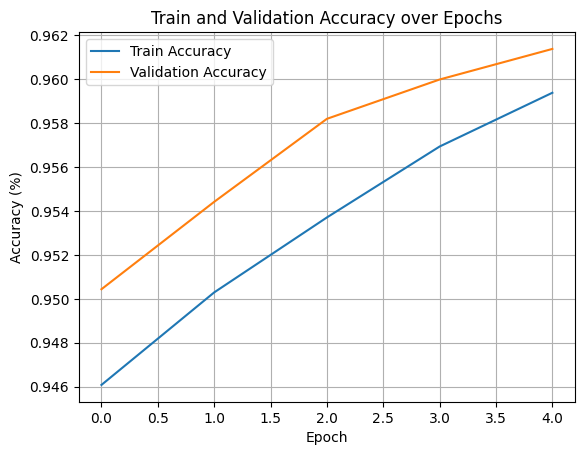

In [13]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



Question 4 Answers

A. Are 5 epochs enough?

Five epochs may not be enough if both the training and validation accuracy curves are still improving at the end of the fifth epoch. This indicates that the model has not yet fully learned the underlying patterns in the data. While smaller datasets such as the 8×8 MNIST digits often reach stable performance within a few epochs, larger 28×28 image datasets combined with deeper neural networks generally benefit from additional training epochs before convergence is achieved.

B. Why does the validation accuracy exceed the training accuracy?

The higher validation accuracy is due to the way training accuracy is calculated in the original implementation. During training, accuracy is measured while the model parameters are continuously being updated. As a result, predictions made on earlier batches are generated using less-optimized weights, which can lead to a lower overall training accuracy estimate.

In contrast, validation accuracy is computed only after the completion of an epoch, using the final set of updated weights. This often results in a more accurate and sometimes higher performance estimate.

To correct this issue, training accuracy should be evaluated after each epoch using a separate evaluation phase. This can be done by switching the model to evaluation mode with model.eval() and disabling gradient calculations using torch.no_grad(), following the same procedure used for validation. This ensures that both training and validation accuracies are measured under comparable conditions. See the corrected training loop below.

Epoch 1: Train=0.8896  Val=0.8964
Epoch 2: Train=0.9090  Val=0.9119
Epoch 3: Train=0.9224  Val=0.9255
Epoch 4: Train=0.9277  Val=0.9291
Epoch 5: Train=0.9357  Val=0.9391


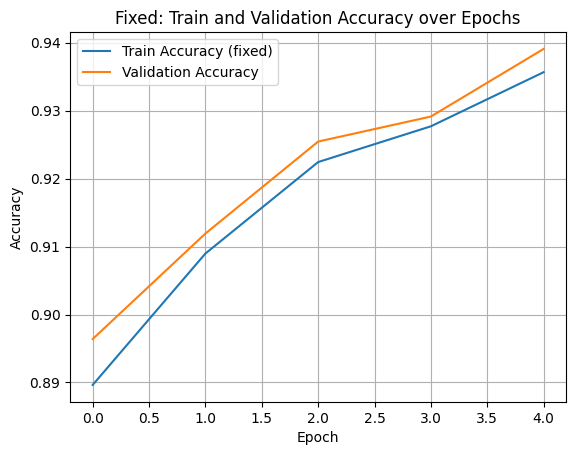

In [24]:
# prompt: Fix the training loop so train accuracy is computed after each full
# epoch in eval mode, making the comparison with validation accuracy fair.
# Modification: added a separate evaluation pass over train_loader after training.

# Imports and definitions that might be missing if cells are run out of order
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the compute_accuracy function (moved from previous cell 0m9K5d8a6e0d)
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# Assuming SimpleNN, input_size, hidden_size, num_classes, device, criterion,
# train_loader, and test_loader are defined in preceding cells or globally accessible.
# If not, they would need to be re-defined here for complete self-containment.

num_epochs = 5
history_fixed = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

model_fixed = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer_fixed = optim.Adam(model_fixed.parameters(), lr=0.001)

for epoch in range(num_epochs):

    # Training phase — update weights only
    model_fixed.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_fixed(images)
        loss = criterion(outputs, labels)
        optimizer_fixed.zero_grad()
        loss.backward()
        optimizer_fixed.step()

    # Evaluate on TRAIN set AFTER full epoch (FIX)
    model_fixed.eval()
    batch_accuracies = []
    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_fixed(images)
            batch_accuracies.append(compute_accuracy(outputs, labels))
    history_fixed['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Evaluate on VALIDATION set
    batch_accuracies = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_fixed(images)
            batch_accuracies.append(compute_accuracy(outputs, labels))
    history_fixed['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))
    history_fixed['epoch'].append(epoch)

    print(f"Epoch {epoch+1}: Train={history_fixed['train_accuracy'][-1]:.4f}  "
          f"Val={history_fixed['val_accuracy'][-1]:.4f}")

# Fixed plot
plt.plot(history_fixed['epoch'], history_fixed['train_accuracy'], label='Train Accuracy (fixed)')
plt.plot(history_fixed['epoch'], history_fixed['val_accuracy'],   label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fixed: Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()